In [1]:
import os
from typing import TypedDict

from dotenv import load_dotenv

from langchain_google_genai import ChatGoogleGenerativeAI

from langgraph.graph import StateGraph
from langgraph.graph import START, END

In [2]:
# ==================================================
# Load Environment Variables
# ==================================================

load_dotenv()

# ==================================================
# Load Gemini API Key
# ==================================================

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

In [7]:
# ==================================================
# Initialize LLM
# ==================================================


llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.3
)

In [3]:
# ==========================================================
# STATE
# ==========================================================

class QAState(TypedDict):
    question: str
    answer: str


In [4]:
# ==========================================================
# NODE
# ==========================================================

def llm_node(state: QAState):

    print("\nLLM Node Running...\n")

    response = llm.invoke(state["question"])

    return {
        "answer": response.content
    }

In [5]:
# ==========================================================
# GRAPH
# ==========================================================

graph_builder = StateGraph(QAState)

graph_builder.add_node("LLM", llm_node)

graph_builder.add_edge(START, "LLM")

graph_builder.add_edge("LLM", END)

graph = graph_builder.compile()

In [9]:
# ==========================================================
# INPUT
# ==========================================================

question = input("Ask a Question: ")

result = graph.invoke(
    {
        "question": question
    }
)

print("\n==========================")
print("Answer")
print("==========================\n")

print(result["answer"])


LLM Node Running...


Answer

The creator of Python is **Guido van Rossum**.

He started working on it in the late 1980s and released the first version in 1991. He remained Python's benevolent dictator for life (BDFL) until July 2018, when he stepped down from that role.


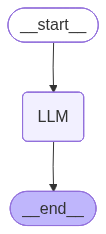

In [11]:

from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())